# EE0848 MACHINE LEARNING FOR SP
## WEEK 5 PRACTICE
### DATA PREPROCESSING, FEATURE ENGINEERING & REGULARIZATION

#### **Click "Copy to Drive" at the top to create your own editable copy of this notebook**
#### **Then run the cells in order from top to bottom**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## 1. Loading the Ames Housing Dataset

The Ames Housing dataset contains 80 features describing residential properties in Ames, Iowa. The target is **SalePrice**.

This dataset is ideal for practicing preprocessing because it has:
- **Missing values** in several columns
- **Categorical features** (both ordinal and nominal)
- **Numerical features** at very different scales

In [2]:
# Load the Ames Housing dataset from OpenML
ames = fetch_openml(name="house_prices", as_frame=True)
df = ames.frame

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# We will work with a selected subset of features to keep things focused
numeric_cols = ['LotArea', 'LotFrontage', 'OverallQual', 'OverallCond',
                'YearBuilt', 'TotalBsmtSF', 'GrLivArea', 'GarageArea', 'MasVnrArea']
ordinal_cols = ['ExterQual', 'KitchenQual']
nominal_cols = ['BldgType', 'CentralAir']
target_col = 'SalePrice'

cols = numeric_cols + ordinal_cols + nominal_cols + [target_col]
df = df[cols].copy()

print(f'Working with {df.shape[1]-1} features and {df.shape[0]} samples')
df.head()

Working with 13 features and 1460 samples


,LotArea,LotFrontage,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,GrLivArea,GarageArea,MasVnrArea,ExterQual,KitchenQual,BldgType,CentralAir,SalePrice
0,8450,65.0,7,5,2003,856,1710,548,196.0,Gd,Gd,1Fam,Y,208500
1,9600,80.0,6,8,1976,1262,1262,460,0.0,TA,TA,1Fam,Y,181500
2,11250,68.0,7,5,2001,920,1786,608,162.0,Gd,Gd,1Fam,Y,223500
3,9550,60.0,7,5,1915,756,1717,642,0.0,TA,Gd,1Fam,Y,140000
4,14260,84.0,8,5,2000,1145,2198,836,350.0,Gd,Gd,1Fam,Y,250000


### Selected Features

We work with a subset of 13 features from the full 80-feature dataset:

**Numeric features:**
- `LotArea` — Lot size in square feet
- `LotFrontage` — Linear feet of street connected to the property (has missing values)
- `OverallQual` — Overall material and finish quality (1–10 scale)
- `OverallCond` — Overall condition rating (1–10 scale)
- `YearBuilt` — Original construction year
- `TotalBsmtSF` — Total basement area in square feet
- `GrLivArea` — Above-ground living area in square feet
- `GarageArea` — Size of garage in square feet
- `MasVnrArea` — Masonry veneer area in square feet (has missing values). This is a decorative outer layer of brick or stone on the house exterior — purely cosmetic, not structural. A value of 0 means no veneer (e.g., all siding).

**Ordinal features** (quality ratings with a natural order):
- `ExterQual` — Exterior material quality
- `KitchenQual` — Kitchen quality
- Values: **Po** (Poor), **Fa** (Fair), **TA** (Typical/Average), **Gd** (Good), **Ex** (Excellent)

**Nominal features** (categories without order):
- `BldgType` — The structural style of the house: is it a standalone house, or does it share walls with neighbors?
  - **1Fam** = Single-family detached (standalone house, no shared walls)
  - **2fmCon** = Two-family conversion (was originally one house, later split into two units)
  - **Duplex** = Two units side by side sharing a wall
  - **TwnhsE** = Townhouse end unit (row house at the end — one shared wall, yard on the other side)
  - **Twnhs** = Townhouse inner unit (row house in the middle — shared walls on both sides)
- `CentralAir` — Central air conditioning (**Y** = Yes, **N** = No)

**Target:** `SalePrice` — Property sale price in dollars

## 2. Handling Missing Data

Real-world datasets almost always have missing values. Before training any model, we need to handle them.

Common strategies:
- **Drop** rows or columns with missing values (`dropna`)
- **Impute** missing values with mean, median, or mode (`SimpleImputer`)

In [4]:
# Check for missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Columns with missing values:\n')
print(missing)
print(f'\nTotal rows: {len(df)}')

Columns with missing values:

LotFrontage    259
MasVnrArea       8
dtype: int64

Total rows: 1460


In [5]:
# Strategy 2: Impute missing values
# For numeric columns: fill with median (robust to outliers)
# For categorical columns: fill with most frequent value (mode)

df_imputed = df.copy()

# Numeric imputation
num_imputer = SimpleImputer(strategy='median')
df_imputed[numeric_cols] = num_imputer.fit_transform(df_imputed[numeric_cols])

# Categorical imputation
cat_imputer = SimpleImputer(strategy='most_frequent')
df_imputed[ordinal_cols + nominal_cols] = cat_imputer.fit_transform(df_imputed[ordinal_cols + nominal_cols])

print('Missing values after imputation:', df_imputed.isnull().sum().sum())

Missing values after imputation: 0


### Exercise 1: Imputation Comparison

**a)** Create a copy of `df` and impute the numeric missing values using `strategy='mean'` instead of `'median'`.

**b)** Compare the imputed values for `LotFrontage`: print the mean and median of the original (non-null) values, and the first 5 imputed values from each strategy.

**c)** Which strategy would you prefer if the feature has outliers? Why?

In [6]:
# Your solution here


## 3. Encoding Categorical Data

Machine learning models work with numbers, not strings. We need to convert categorical features to numeric representations.

- **Ordinal encoding:** For categories with a natural order (e.g., quality ratings)
- **One-hot encoding:** For categories without order (e.g., building type)

In [7]:
# Check our categorical columns
print('Ordinal features:')
for col in ordinal_cols:
    print(f'  {col}: {df_imputed[col].unique()}')

print('\nNominal features:')
for col in nominal_cols:
    print(f'  {col}: {df_imputed[col].unique()}')

Ordinal features:
  ExterQual: ['Gd' 'TA' 'Ex' 'Fa']
  KitchenQual: ['Gd' 'TA' 'Ex' 'Fa']

Nominal features:
  BldgType: ['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']
  CentralAir: ['Y' 'N']


In [8]:
# Ordinal encoding: map quality ratings to numbers
# ExterQual and KitchenQual share the same scale: Po < Fa < TA < Gd < Ex
quality_map = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

df_encoded = df_imputed.copy()
for col in ordinal_cols:
    df_encoded[col] = df_encoded[col].map(quality_map)

print('After ordinal encoding:')
df_encoded[ordinal_cols].head()

After ordinal encoding:


,ExterQual,KitchenQual
0,4,4
1,3,3
2,4,4
3,3,4
4,4,4


In [9]:
# One-hot encoding: for nominal features without natural order
df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, drop_first=True)

print(f'Shape after one-hot encoding: {df_encoded.shape}')
print(f'\nNew columns: {[c for c in df_encoded.columns if "_" in c and c != target_col]}')
df_encoded.head()

Shape after one-hot encoding: (1460, 17)

New columns: ['BldgType_2fmCon', 'BldgType_Duplex', 'BldgType_Twnhs', 'BldgType_TwnhsE', 'CentralAir_Y']


,LotArea,LotFrontage,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,GrLivArea,GarageArea,MasVnrArea,ExterQual,KitchenQual,SalePrice,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,CentralAir_Y
0,8450.0,65.0,7.0,5.0,2003.0,856.0,1710.0,548.0,196.0,4,4,208500,False,False,False,False,True
1,9600.0,80.0,6.0,8.0,1976.0,1262.0,1262.0,460.0,0.0,3,3,181500,False,False,False,False,True
2,11250.0,68.0,7.0,5.0,2001.0,920.0,1786.0,608.0,162.0,4,4,223500,False,False,False,False,True
3,9550.0,60.0,7.0,5.0,1915.0,756.0,1717.0,642.0,0.0,3,4,140000,False,False,False,False,True
4,14260.0,84.0,8.0,5.0,2000.0,1145.0,2198.0,836.0,350.0,4,4,250000,False,False,False,False,True


### Exercise 2: Encoding

**a)** What happens if you use `pd.get_dummies` **without** `drop_first=True`? How many columns would you get for `BldgType`?

**b)** Why do we use manual mapping for `ExterQual` instead of one-hot encoding? What would go wrong if we one-hot encoded it?

In [10]:
# Your solution here


## 4. Feature Scaling

Features at different scales can cause problems for many ML algorithms (especially regularized models). Let's compare two common scaling methods:

- **StandardScaler** (Z-score): $x_{std} = \frac{x - \mu}{\sigma}$ → mean=0, std=1
- **MinMaxScaler**: $x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$ → range [0, 1]

In [11]:
# Prepare features and target
X = df_encoded.drop(target_col, axis=1).values.astype(float)
y = df_encoded[target_col].values.astype(float)
feature_names = df_encoded.drop(target_col, axis=1).columns.tolist()

# Split data FIRST, then scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit scalers on training data only
std_scaler = StandardScaler()
mm_scaler = MinMaxScaler()

X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm = mm_scaler.transform(X_test)

print('Original range of LotArea (col 0):')
print(f'  Train: [{X_train[:, 0].min():.0f}, {X_train[:, 0].max():.0f}]')
print(f'\nAfter StandardScaler:')
print(f'  Train: [{X_train_std[:, 0].min():.2f}, {X_train_std[:, 0].max():.2f}]')
print(f'\nAfter MinMaxScaler:')
print(f'  Train: [{X_train_mm[:, 0].min():.2f}, {X_train_mm[:, 0].max():.2f}]')

Original range of LotArea (col 0):
  Train: [1300, 215245]

After StandardScaler:
  Train: [-0.87, 19.02]

After MinMaxScaler:
  Train: [0.00, 1.00]


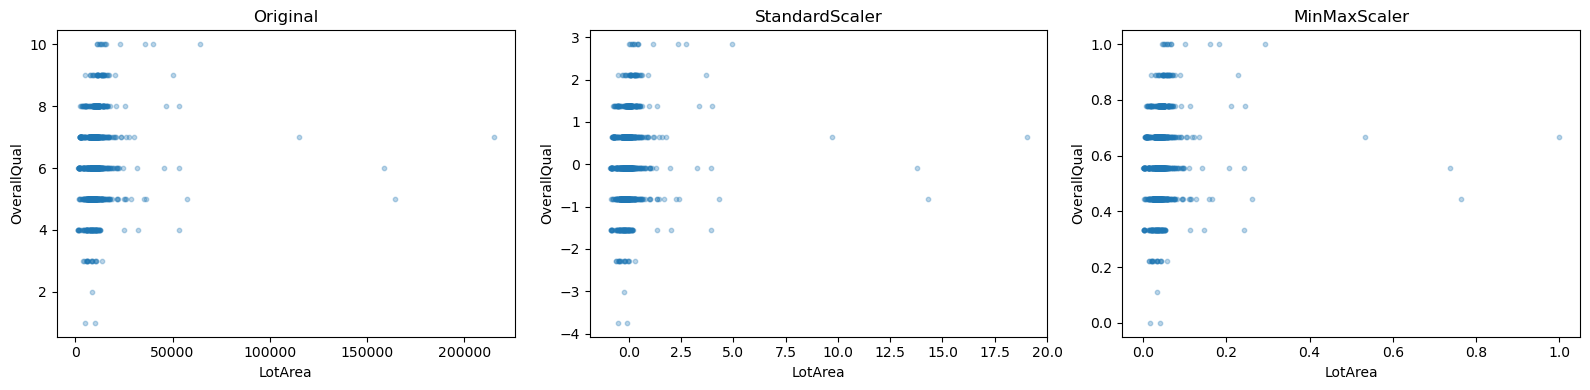

In [12]:
# Visualize the effect of scaling on two features with very different ranges
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Feature indices: LotArea (0) and OverallQual (2)
i, j = 0, 2

axes[0].scatter(X_train[:, i], X_train[:, j], alpha=0.3, s=10)
axes[0].set_xlabel(feature_names[i])
axes[0].set_ylabel(feature_names[j])
axes[0].set_title('Original')

axes[1].scatter(X_train_std[:, i], X_train_std[:, j], alpha=0.3, s=10)
axes[1].set_xlabel(feature_names[i])
axes[1].set_ylabel(feature_names[j])
axes[1].set_title('StandardScaler')

axes[2].scatter(X_train_mm[:, i], X_train_mm[:, j], alpha=0.3, s=10)
axes[2].set_xlabel(feature_names[i])
axes[2].set_ylabel(feature_names[j])
axes[2].set_title('MinMaxScaler')

plt.tight_layout()
plt.show()

### Exercise 3: Scaling Leak

**a)** What happens if you fit the scaler on the **entire** dataset (train + test) instead of just the training set? Why is this a problem?

**b)** Demonstrate: fit `StandardScaler` on `X` (all data), transform both train and test, and compare the test set mean to when you fit only on `X_train`.

In [13]:
# Your solution here


## 5. Feature Engineering

We can create new features from existing ones to help models capture nonlinear relationships.

- **Polynomial features:** $x, x^2, x^3, ...$
- **Interaction features:** $x_1 \cdot x_2$

In [14]:
# Demonstrate PolynomialFeatures on a small example
from sklearn.preprocessing import PolynomialFeatures

# Take just 2 features to see what happens
X_demo = X_train_std[:5, :2]
print('Original (first 2 features, 5 samples):')
print(X_demo.round(2))

# Degree 2: includes x0, x1, x0^2, x0*x1, x1^2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_demo)
print(f'\nPolynomialFeatures(degree=2): {X_demo.shape} -> {X_poly.shape}')
print(f'Features: {poly.get_feature_names_out(["x0", "x1"])}')
print(X_poly.round(2))

# Interaction-only: includes x0, x1, x0*x1 (no squared terms)
poly_inter = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_inter = poly_inter.fit_transform(X_demo)
print(f'\ninteraction_only=True: {X_demo.shape} -> {X_inter.shape}')
print(f'Features: {poly_inter.get_feature_names_out(["x0", "x1"])}')
print(X_inter.round(2))

Original (first 2 features, 5 samples):
[[-0.21 -0.  ]
 [-0.27 -0.49]
 [-0.18 -0.14]
 [-0.32 -0.45]
 [-0.53 -0.89]]

PolynomialFeatures(degree=2): (5, 2) -> (5, 5)
Features: ['x0' 'x1' 'x0^2' 'x0 x1' 'x1^2']
[[-0.21 -0.    0.05  0.    0.  ]
 [-0.27 -0.49  0.07  0.13  0.24]
 [-0.18 -0.14  0.03  0.02  0.02]
 [-0.32 -0.45  0.11  0.15  0.2 ]
 [-0.53 -0.89  0.28  0.47  0.8 ]]

interaction_only=True: (5, 2) -> (5, 3)
Features: ['x0' 'x1' 'x0 x1']
[[-0.21 -0.    0.  ]
 [-0.27 -0.49  0.13]
 [-0.18 -0.14  0.02]
 [-0.32 -0.45  0.15]
 [-0.53 -0.89  0.47]]


In [15]:
# Compare: Linear Regression with and without polynomial features
# Using a pipeline to keep things clean

lr = make_pipeline(StandardScaler(), LinearRegression())
lr_poly = make_pipeline(StandardScaler(),
                        PolynomialFeatures(degree=2, include_bias=False),
                        LinearRegression())

# Fit both models and get training scores
lr.fit(X_train, y_train)
lr_poly.fit(X_train, y_train)

print(f'{"Model":<30} {"Train R²":>10} {"CV R² (mean ± std)":>25}')
print('-' * 67)

scores_lr = cross_val_score(lr, X_train, y_train, cv=5, scoring='r2')
print(f'{"Linear Regression":<30} {lr.score(X_train, y_train):>10.4f} {scores_lr.mean():>10.4f} (+/- {scores_lr.std():.4f})')

scores_poly = cross_val_score(lr_poly, X_train, y_train, cv=5, scoring='r2')
print(f'{"With Polynomial (deg=2)":<30} {lr_poly.score(X_train, y_train):>10.4f} {scores_poly.mean():>10.4f} (+/- {scores_poly.std():.4f})')

print('\n→ Notice: Polynomial has near-perfect training R² but terrible CV R².')
print('  This is classic overfitting — the model memorizes training data but fails on unseen data.')

Model                            Train R²        CV R² (mean ± std)
-------------------------------------------------------------------
Linear Regression                  0.7939     0.7774 (+/- 0.0828)
With Polynomial (deg=2)            0.8957    -0.1461 (+/- 1.5551)

→ Notice: Polynomial has near-perfect training R² but terrible CV R².
  This is classic overfitting — the model memorizes training data but fails on unseen data.


## 6. Regularization

Adding polynomial features increases model capacity but also increases the risk of **overfitting**. Regularization adds a penalty on large coefficients to keep the model simpler.

- **Ridge (L2):** $J = MSE + \alpha \sum w_j^2$ — shrinks coefficients, keeps all features
- **Lasso (L1):** $J = MSE + \alpha \sum |w_j|$ — can zero out coefficients → feature selection
- **Elastic Net:** $J = MSE + \alpha_1 \sum |w_j| + \alpha_2 \sum w_j^2$ — combines both

**Important:** In scikit-learn, Ridge/Lasso/ElasticNet use `alpha` (= $\lambda$). Larger alpha = stronger regularization.

In [ ]:
# Compare unregularized vs regularized on polynomial features
models = {
    'LinearRegression':       make_pipeline(StandardScaler(), PolynomialFeatures(degree=2, include_bias=False), LinearRegression()),
    'Ridge (alpha=1)':        make_pipeline(StandardScaler(), PolynomialFeatures(degree=2, include_bias=False), Ridge(alpha=1.0)),
    'Ridge (alpha=1000)':     make_pipeline(StandardScaler(), PolynomialFeatures(degree=2, include_bias=False), Ridge(alpha=1000)),
    'Lasso (alpha=1)':        make_pipeline(StandardScaler(), PolynomialFeatures(degree=2, include_bias=False), Lasso(alpha=1.0)),
    'Lasso (alpha=1000)':     make_pipeline(StandardScaler(), PolynomialFeatures(degree=2, include_bias=False), Lasso(alpha=1000, max_iter=10000)),
    'ElasticNet (alpha=1)':   make_pipeline(StandardScaler(), PolynomialFeatures(degree=2, include_bias=False), ElasticNet(alpha=1.0, l1_ratio=0.5)),
}

print(f'{"Model":<30} {"Train R²":>10} {"CV R² (mean ± std)":>25}')
print('-' * 67)

for name, model in models.items():
    model.fit(X_train, y_train)
    train_r2 = model.score(X_train, y_train)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    print(f'{name:<30} {train_r2:>10.4f} {cv_scores.mean():>10.4f} (+/- {cv_scores.std():.4f})')

### 6.1 Regularization Paths

How do coefficients change as we increase the regularization strength?

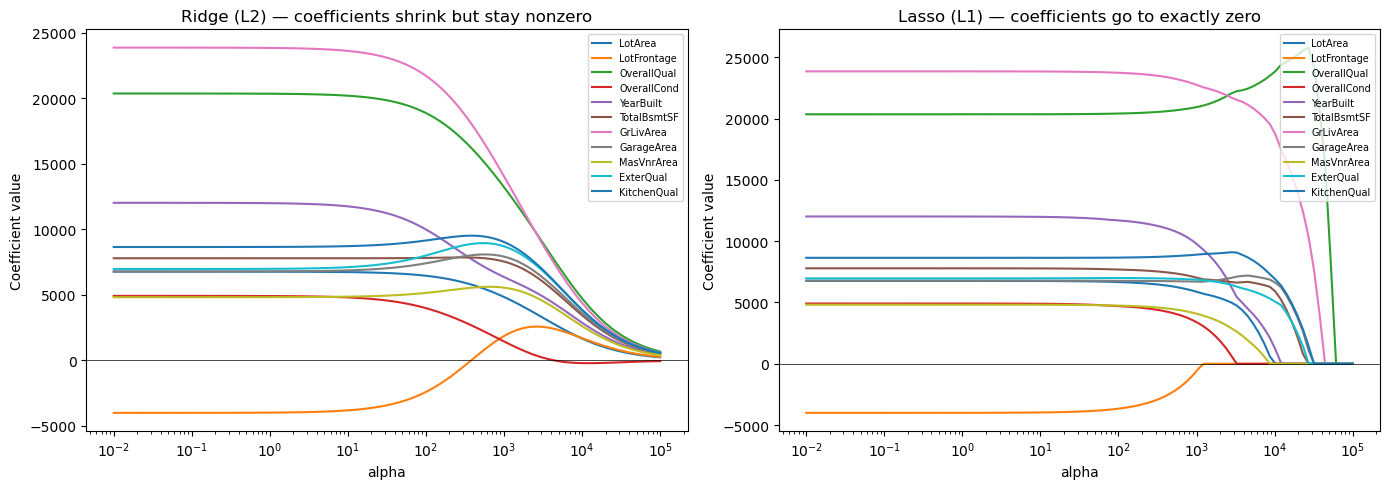

In [17]:
# Regularization paths: Ridge vs Lasso
alphas = np.logspace(-2, 5, 100)

ridge_coefs = []
lasso_coefs = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_std, y_train)
    ridge_coefs.append(ridge.coef_)
    
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_std, y_train)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Only plot the original numeric + ordinal features (not one-hot columns)
n_main = len(numeric_cols + ordinal_cols)
for i in range(n_main):
    axes[0].plot(alphas, ridge_coefs[:, i], label=feature_names[i])
    axes[1].plot(alphas, lasso_coefs[:, i], label=feature_names[i])

axes[0].set_xscale('log')
axes[0].set_xlabel('alpha')
axes[0].set_ylabel('Coefficient value')
axes[0].set_title('Ridge (L2) — coefficients shrink but stay nonzero')
axes[0].legend(fontsize=7, loc='upper right')
axes[0].axhline(0, color='black', linewidth=0.5)

axes[1].set_xscale('log')
axes[1].set_xlabel('alpha')
axes[1].set_ylabel('Coefficient value')
axes[1].set_title('Lasso (L1) — coefficients go to exactly zero')
axes[1].legend(fontsize=7, loc='upper right')
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

In [18]:
# Lasso feature selection: which features survive at different alpha values?
for a in [1, 10, 100, 1000]:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_std, y_train)
    n_nonzero = np.sum(lasso.coef_ != 0)
    selected = [feature_names[i] for i in range(len(feature_names)) if lasso.coef_[i] != 0]
    print(f'alpha={a:<5d} → {n_nonzero} features: {selected}')

alpha=1     → 16 features: ['LotArea', 'LotFrontage', 'OverallQual', 'OverallCond', 'YearBuilt', 'TotalBsmtSF', 'GrLivArea', 'GarageArea', 'MasVnrArea', 'ExterQual', 'KitchenQual', 'BldgType_2fmCon', 'BldgType_Duplex', 'BldgType_Twnhs', 'BldgType_TwnhsE', 'CentralAir_Y']
alpha=10    → 16 features: ['LotArea', 'LotFrontage', 'OverallQual', 'OverallCond', 'YearBuilt', 'TotalBsmtSF', 'GrLivArea', 'GarageArea', 'MasVnrArea', 'ExterQual', 'KitchenQual', 'BldgType_2fmCon', 'BldgType_Duplex', 'BldgType_Twnhs', 'BldgType_TwnhsE', 'CentralAir_Y']
alpha=100   → 15 features: ['LotArea', 'LotFrontage', 'OverallQual', 'OverallCond', 'YearBuilt', 'TotalBsmtSF', 'GrLivArea', 'GarageArea', 'MasVnrArea', 'ExterQual', 'KitchenQual', 'BldgType_2fmCon', 'BldgType_Duplex', 'BldgType_Twnhs', 'BldgType_TwnhsE']
alpha=1000  → 14 features: ['LotArea', 'LotFrontage', 'OverallQual', 'OverallCond', 'YearBuilt', 'TotalBsmtSF', 'GrLivArea', 'GarageArea', 'MasVnrArea', 'ExterQual', 'KitchenQual', 'BldgType_Duplex', 

### Exercise 4: Ridge vs Lasso

**a)** Train both Ridge and Lasso with `alpha=1000` on the **scaled** training data. Print the coefficients of each model. Which model has more zero coefficients?

**b)** Which features does Lasso consider most important (largest absolute coefficient)?

In [19]:
# Your solution here


## 7. Putting It All Together: Full Pipeline

A `Pipeline` chains all preprocessing and modeling steps into one object. This ensures:
- Scaling is always fit on training data and applied consistently
- No data leakage between train and test
- Clean, reproducible code

In [20]:
# Full pipeline: Scale -> Polynomial Features -> Ridge Regression
pipe_ridge = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, interaction_only=True, include_bias=False),
    Ridge(alpha=1000)
)

pipe_lasso = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, interaction_only=True, include_bias=False),
    Lasso(alpha=1000, max_iter=10000)
)

# Cross-validation
scores_ridge = cross_val_score(pipe_ridge, X_train, y_train, cv=5, scoring='r2')
scores_lasso = cross_val_score(pipe_lasso, X_train, y_train, cv=5, scoring='r2')

print(f'Ridge Pipeline: R² = {scores_ridge.mean():.4f} (+/- {scores_ridge.std():.4f})')
print(f'Lasso Pipeline: R² = {scores_lasso.mean():.4f} (+/- {scores_lasso.std():.4f})')

Ridge Pipeline: R² = 0.7164 (+/- 0.0868)
Lasso Pipeline: R² = 0.7747 (+/- 0.1084)


Final Ridge Pipeline on Test Set:
  RMSE: $35,315
  R²:   0.8374


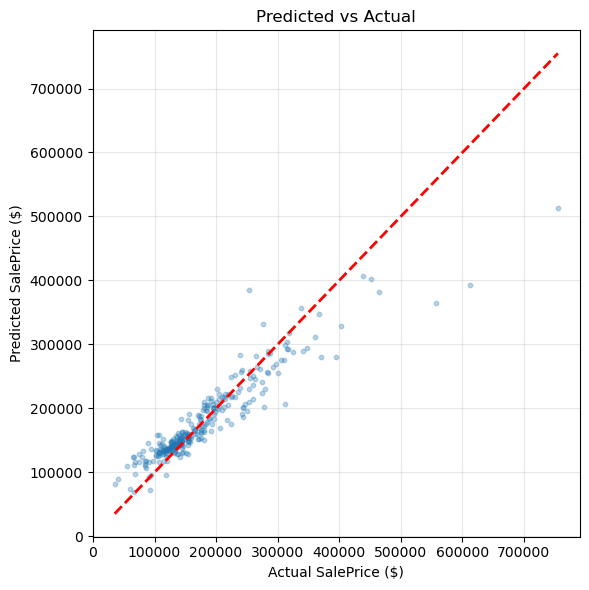

In [21]:
# Final evaluation on the test set
pipe_ridge.fit(X_train, y_train)
y_pred = pipe_ridge.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'Final Ridge Pipeline on Test Set:')
print(f'  RMSE: ${rmse:,.0f}')
print(f'  R²:   {r2:.4f}')

# Scatter plot: predicted vs actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual SalePrice ($)')
plt.ylabel('Predicted SalePrice ($)')
plt.title('Predicted vs Actual')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

- **Missing data:** Identify, then drop or impute (median for numeric, mode for categorical)
- **Categorical encoding:** Ordinal mapping for ordered categories, one-hot for nominal
- **Scaling:** Always fit on training data, transform both train and test
- **Feature engineering:** Polynomial and interaction features help capture nonlinear patterns
- **Regularization:** Ridge (L2) shrinks all coefficients; Lasso (L1) zeros out irrelevant features
- **Pipelines:** Chain all steps together for clean, leak-free workflows